In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0 # 왜 1을 썼는지 기억하기

train_scaled, val_scaled, train_target, val_target = train_test_split(
                                                        train_scaled,
                                                        train_target,
                                                        test_size= 0.2,
                                                        random_state=42
)
train_scaled.shape

(48000, 28, 28, 1)

#### 첫번째 합성곱 층

In [3]:
model = keras.Sequential()

In [4]:

model.add(
        keras.layers.Conv2D(
            32, # 필터를 32개
            kernel_size=3,  # 사이즈 설정
            activation='relu',
            padding='same',
            input_shape = (28, 28, 1)
        )
)

In [5]:
model.add(keras.layers.MaxPool2D(2))

### 두번째 합성곱 층

In [6]:

model.add(
        keras.layers.Conv2D(
            64, # 필터를 32개
            kernel_size=3,  # 사이즈 설정
            activation='relu',
            padding='same',
            # 들어온 값을 쓰니까 인푹데이터가 필요하지 않음
        )
)
model.add(keras.layers.MaxPool2D(2))

#### 완전 연결층

In [ ]:
model.add(keras.layers.Flatten()) # 한줄로 펴지게 하는 거 
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dropout(0.5)) # 시각화 본 뒤에 dropout 추가
model.add(keras.layers.Dense(10,activation='softmax'))

In [8]:
# model.add(keras.layers.Flatten())
# model.add(keras.layers.Dense(100,activation='relu'))
# model.add(keras.layers.Dense(10,activation='softmax'))

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Compile과 훈련

In [ ]:
# model에 dropout층을 추가 
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_cnn_model.keras')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,restore_best_weights=True) # 다시 2번 복기한다 patience ( 2번떨어지면 저장 안하고 끝이다 , for문 생각하면 된다 )

history = model.fit(
    train_scaled,train_target,epochs=20,
                    validation_data=(val_scaled,val_target),
                    callbacks = [checkpoint_cb,early_stopping_cb]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7925 - loss: 0.5829 - val_accuracy: 0.8745 - val_loss: 0.3469
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8648 - loss: 0.3815 - val_accuracy: 0.8901 - val_loss: 0.2912
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8818 - loss: 0.3291 - val_accuracy: 0.9029 - val_loss: 0.2586
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8943 - loss: 0.2925 - val_accuracy: 0.9095 - val_loss: 0.2477
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9033 - loss: 0.2673 - val_accuracy: 0.9140 - val_loss: 0.2360
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9100 - loss: 0.2486 - val_accuracy: 0.9156 - val_loss: 0.2329
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9157 - loss: 0.2290 - val_accuracy: 0.9187 - val_loss: 0.2236
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9205 - loss: 

In [11]:
import matplotlib.pyplot as plt

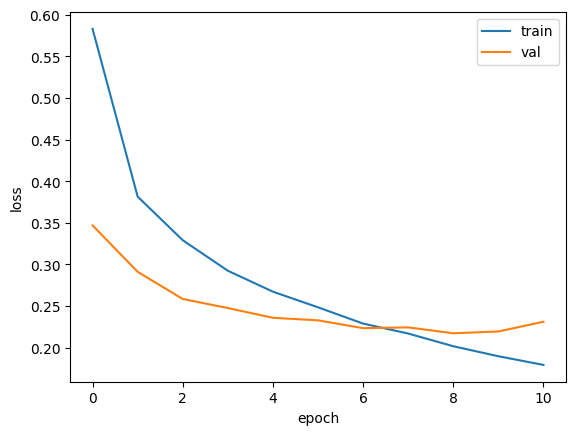

In [12]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

#### 평가와 예측

In [13]:
# 검증 데이터 
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9222 - loss: 0.2174


[0.2173936814069748, 0.922166645526886]

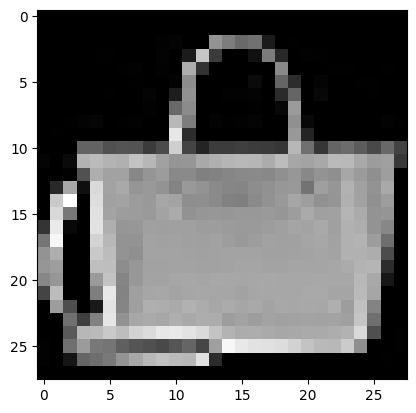

In [14]:
# 이미지 확인하기
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray') # imshow라서 2차원데이터 바꿔서 보여줌,그림 그리려고 리쉐이프 한 거
plt.show()

In [15]:
preds = model.predict(val_scaled[0:0+1]) # 인덱싱과 다르게 슬라이싱은 본인 타입을 가지고 들어가기때문에 슬라이싱으로 해줘야 함
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[3.4122946e-18 1.1772378e-28 1.0320163e-20 4.9764966e-20 4.4659574e-21
  1.3638261e-17 2.3499876e-19 9.0255048e-22 1.0000000e+00 4.4284992e-21]]


In [16]:
# 글자로 변경하기 
import numpy as np

classes = ['티셔츠', '바지', '스웨터','드레스','코트','샌들','셔츠','스니커즈','가방','앵글 부츠']

print(classes[np.argmax(preds)])

가방
